In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import imblearn
import itertools
import sys
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn import metrics as metrics
import warnings
warnings.filterwarnings('ignore')

In [2]:
datacols = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","attack", "last_flag"]

train = pd.read_table("KDDTrain.txt", sep=",", names=datacols) 
train = train.iloc[:,:-1] 

test = pd.read_table("KDDTest.txt", sep=",", names=datacols)
test = test.iloc[:,:-1]

In [3]:

mapping = {'ipsweep': 'Probe','satan': 'Probe','nmap': 'Probe','portsweep': 'Probe','saint': 'Probe','mscan': 'Probe',
        'teardrop': 'DoS','pod': 'DoS','land': 'DoS','back': 'DoS','neptune': 'DoS','smurf': 'DoS','mailbomb': 'DoS',
        'udpstorm': 'DoS','apache2': 'DoS','processtable': 'DoS',
        'perl': 'U2R','loadmodule': 'U2R','rootkit': 'U2R','buffer_overflow': 'U2R','xterm': 'U2R','ps': 'U2R',
        'sqlattack': 'U2R','httptunnel': 'U2R',
        'ftp_write': 'R2L','phf': 'R2L','guess_passwd': 'R2L','warezmaster': 'R2L','warezclient': 'R2L','imap': 'R2L',
        'spy': 'R2L','multihop': 'R2L','named': 'R2L','snmpguess': 'R2L','worm': 'R2L','snmpgetattack': 'R2L',
        'xsnoop': 'R2L','xlock': 'R2L','sendmail': 'R2L',
        'normal': 'Normal'
        }

train['attack_class'] = train['attack'].apply(lambda v: mapping[v])
test['attack_class'] = test['attack'].apply(lambda v: mapping[v])

In [4]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,attack_class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,DoS
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,Normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,Normal


In [5]:
test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,attack_class
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,DoS
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,DoS
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,Normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,Probe
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,Probe


In [6]:
train.shape

(125973, 43)

In [7]:
test.shape

(22544, 43)

In [8]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
test.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,193.869411,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,94.035663,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,121.000000,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


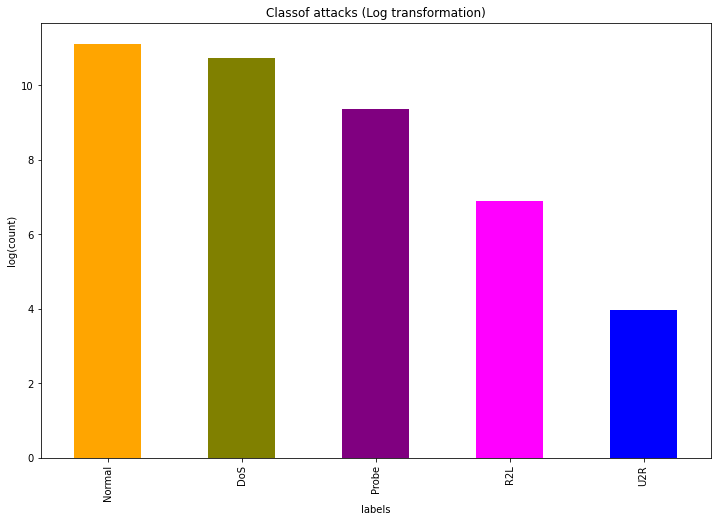

In [10]:
plt.figure(figsize=(12,8))
plt.title('Classof attacks (Log transformation)')
train['attack_class'].value_counts().apply(np.log).plot(kind='bar', color = ['orange','Olive','purple','Fuchsia','blue'])
plt.xlabel("labels")
plt.ylabel("log(count)")
plt.show()

In [11]:
def bar_graph(feature):
    train[feature].value_counts().plot(kind="bar")

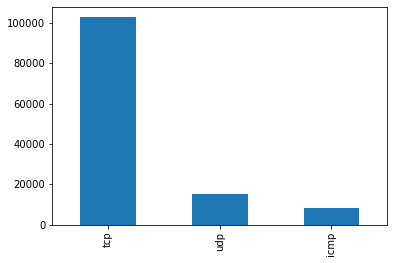

In [12]:
bar_graph('protocol_type')

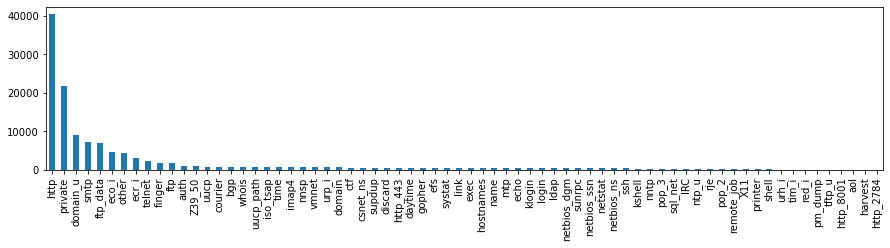

In [13]:
plt.figure(figsize=(15,3))
bar_graph('service')

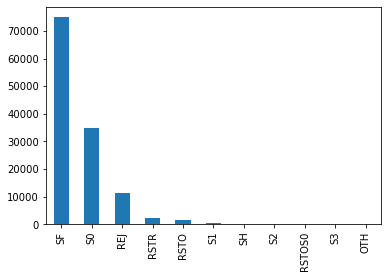

In [14]:
bar_graph('flag')

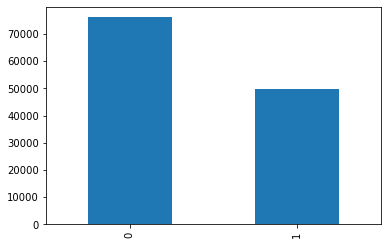

In [15]:
bar_graph('logged_in')

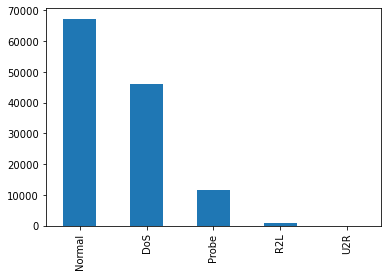

In [16]:
bar_graph('attack_class')

In [17]:
train = train.drop(['land','su_attempted','num_outbound_cmds','is_host_login','urgent','num_failed_logins','su_attempted','num_file_creations','num_shells','srv_diff_host_rate'], axis = 1)
test = test.drop(['land','su_attempted','num_outbound_cmds','is_host_login','urgent','num_failed_logins','su_attempted','num_file_creations','num_shells','srv_diff_host_rate'], axis = 1)

In [18]:
y = train["attack_class"].values
from collections import Counter
Counter(y)

Counter({'Normal': 67343, 'DoS': 45927, 'R2L': 995, 'Probe': 11656, 'U2R': 52})

In [19]:
y1 = test["attack_class"].values
from collections import Counter
Counter(y1)

Counter({'DoS': 7458, 'Normal': 9711, 'Probe': 2421, 'R2L': 2754, 'U2R': 200})

In [20]:
from sklearn.preprocessing import LabelEncoder
encodings = dict()
for c in train.columns:
    
    if train[c].dtype == "object":
        encodings[c] = LabelEncoder()
        encodings[c]
        train[c] = encodings[c].fit_transform(train[c])

In [21]:
y = train.pop("attack_class").values
X = train.values

In [22]:
train.dtypes

duration                         int64
protocol_type                    int32
service                          int32
flag                             int32
src_bytes                        int64
dst_bytes                        int64
wrong_fragment                   int64
hot                              int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
num_root                         int64
num_access_files                 int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate                float64
rerror_rate                    float64
srv_rerror_rate                float64
same_srv_rate                  float64
diff_srv_rate                  float64
dst_host_count                   int64
dst_host_srv_count               int64
dst_host_same_srv_rate         float64
dst_host_diff_srv_rate   

In [23]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X)
principalDfX = pd.DataFrame(data = principalComponents)

In [25]:
principalDfX.head()
print(Counter(y))

Counter({1: 67343, 0: 45927, 2: 11656, 3: 995, 4: 52})


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(principalDfX, y, test_size=0.2, random_state=42)

In [27]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train, y_train)


KNeighborsClassifier()

In [28]:
y_pred = neigh.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 13294, 0: 9289, 2: 2415, 3: 195, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [29]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 9038   121    21     1     0]
 [  202 13016   179    23     2]
 [   45   124  2181     7     0]
 [    4    22    34   164     0]
 [    0    11     0     0     0]]
Accuracy Score : 0.9684064298471919
Report : 
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      9181
           1       0.98      0.97      0.97     13422
           2       0.90      0.93      0.91      2357
           3       0.84      0.73      0.78       224
           4       0.00      0.00      0.00        11

    accuracy                           0.97     25195
   macro avg       0.74      0.72      0.73     25195
weighted avg       0.97      0.97      0.97     25195



In [30]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.9687034868721348
Report : 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     36746
           1       0.98      0.97      0.97     53921
           2       0.91      0.92      0.91      9299
           3       0.80      0.68      0.73       771
           4       0.50      0.05      0.09        41

    accuracy                           0.97    100778
   macro avg       0.83      0.72      0.74    100778
weighted avg       0.97      0.97      0.97    100778



In [31]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train, y_train)

SVC(decision_function_shape='ovo', gamma='auto')

In [32]:
y_pred=clf.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 13802, 0: 8974, 2: 2288, 3: 131})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [33]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 8583   576    22     0     0]
 [  257 12856   300     9     0]
 [  111   335  1911     0     0]
 [   23    25    54   122     0]
 [    0    10     1     0     0]]
Accuracy Score : 0.9316134153601905
Report : 
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      9181
           1       0.93      0.96      0.94     13422
           2       0.84      0.81      0.82      2357
           3       0.93      0.54      0.69       224
           4       0.00      0.00      0.00        11

    accuracy                           0.93     25195
   macro avg       0.73      0.65      0.68     25195
weighted avg       0.93      0.93      0.93     25195



In [34]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.9341522951437814
Report : 
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     36746
           1       0.93      0.96      0.95     53921
           2       0.84      0.82      0.83      9299
           3       0.90      0.50      0.65       771
           4       0.00      0.00      0.00        41

    accuracy                           0.93    100778
   macro avg       0.73      0.64      0.67    100778
weighted avg       0.93      0.93      0.93    100778



In [35]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train, y_train)

In [36]:
y_pred = clf.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 15101, 0: 9181, 2: 913})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [37]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Accuracy Score : 0.8565588410398889
Report : 
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      9181
           1       0.85      0.95      0.90     13422
           2       0.60      0.23      0.33      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.86     25195
   macro avg       0.47      0.42      0.43     25195
weighted avg       0.83      0.86      0.84     25195



In [38]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.8607533390224057
Report : 
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     36746
           1       0.85      0.95      0.90     53921
           2       0.60      0.24      0.35      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.86    100778
   macro avg       0.47      0.42      0.43    100778
weighted avg       0.84      0.86      0.84    100778



In [39]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train, y_train)
clf

MLPClassifier(alpha=1)

In [40]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 8234   937    10     0     0]
 [  270 12802   350     0     0]
 [  674  1138   545     0     0]
 [    3   213     8     0     0]
 [    0    11     0     0     0]]
Accuracy Score : 0.8565588410398889
Report : 
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      9181
           1       0.85      0.95      0.90     13422
           2       0.60      0.23      0.33      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.86     25195
   macro avg       0.47      0.42      0.43     25195
weighted avg       0.83      0.86      0.84     25195



In [41]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.8958998987874338
Report : 
              precision    recall  f1-score   support

           0       0.97      0.90      0.93     36746
           1       0.86      1.00      0.92     53921
           2       0.87      0.39      0.54      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.90    100778
   macro avg       0.54      0.46      0.48    100778
weighted avg       0.89      0.90      0.88    100778



In [42]:
#RandomForest
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
_ = forest.fit(X_train, y_train)
arr = forest.predict(X_train).astype(int)
print(classification_report(y_train, arr))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     36746
           1       0.95      0.95      0.95     53921
           2       0.94      0.71      0.81      9299
           3       0.97      0.47      0.63       771
           4       0.00      0.00      0.00        41

    accuracy                           0.94    100778
   macro avg       0.76      0.63      0.67    100778
weighted avg       0.94      0.94      0.94    100778



In [43]:
arr = forest.predict(X_test).astype(int)
print(classification_report(y_test, arr))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      9181
           1       0.94      0.94      0.94     13422
           2       0.93      0.67      0.78      2357
           3       0.99      0.52      0.68       224
           4       0.00      0.00      0.00        11

    accuracy                           0.93     25195
   macro avg       0.75      0.62      0.67     25195
weighted avg       0.93      0.93      0.93     25195



In [44]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)
y_pred  =  classifier.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90     36746
           1       0.85      0.93      0.89     53921
           2       0.56      0.44      0.49      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.86    100778
   macro avg       0.47      0.45      0.46    100778
weighted avg       0.85      0.86      0.85    100778



In [45]:
y_pred  =  classifier.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      9181
           1       0.85      0.93      0.89     13422
           2       0.57      0.43      0.49      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.86     25195
   macro avg       0.47      0.45      0.45     25195
weighted avg       0.84      0.86      0.85     25195



In [46]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train, y_train)
y_pred = clf_entropy.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.89      0.94     36746
           1       0.85      1.00      0.92     53921
           2       0.96      0.43      0.59      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.90    100778
   macro avg       0.56      0.46      0.49    100778
weighted avg       0.90      0.90      0.89    100778



In [47]:
y_pred = clf_entropy.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.89      0.93      9181
           1       0.85      1.00      0.92     13422
           2       0.96      0.41      0.58      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.89     25195
   macro avg       0.56      0.46      0.48     25195
weighted avg       0.90      0.89      0.88     25195



In [48]:
#DecisionTree Gini Index
clf_gini = DecisionTreeClassifier(criterion = "gini",random_state = 100,max_depth=3, min_samples_leaf=5)
clf_gini.fit(X_train, y_train)
y_pred = clf_gini.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94     36746
           1       0.86      0.99      0.92     53921
           2       0.96      0.43      0.59      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.90    100778
   macro avg       0.56      0.46      0.49    100778
weighted avg       0.90      0.90      0.89    100778



In [49]:
y_pred = clf_gini.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      9181
           1       0.85      0.99      0.91     13422
           2       0.96      0.42      0.58      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.89     25195
   macro avg       0.56      0.46      0.49     25195
weighted avg       0.89      0.89      0.88     25195



In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
principalComponents = pca.fit_transform(X)
principalDfX = pd.DataFrame(data = principalComponents)

In [26]:
principalDfX.head()
print(Counter(y))

Counter({1: 67343, 0: 45927, 2: 11656, 3: 995, 4: 52})


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(principalDfX, y, test_size=0.2, random_state=42)

In [28]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train, y_train)


KNeighborsClassifier()

In [29]:
y_pred = neigh.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 13385, 0: 9189, 2: 2393, 3: 225, 4: 3})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [30]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 9133    36    12     0     0]
 [   37 13290    78    16     1]
 [   18    38  2301     0     0]
 [    0    13     2   209     0]
 [    1     8     0     0     2]]
Accuracy Score : 0.9896804921611431
Report : 
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9181
           1       0.99      0.99      0.99     13422
           2       0.96      0.98      0.97      2357
           3       0.93      0.93      0.93       224
           4       0.67      0.18      0.29        11

    accuracy                           0.99     25195
   macro avg       0.91      0.82      0.83     25195
weighted avg       0.99      0.99      0.99     25195



In [31]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.990216118597313
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     36746
           1       0.99      0.99      0.99     53921
           2       0.97      0.98      0.97      9299
           3       0.90      0.90      0.90       771
           4       0.75      0.37      0.49        41

    accuracy                           0.99    100778
   macro avg       0.92      0.85      0.87    100778
weighted avg       0.99      0.99      0.99    100778



In [32]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train, y_train)

SVC(decision_function_shape='ovo', gamma='auto')

In [33]:
y_pred=clf.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 13489, 0: 9142, 2: 2428, 3: 132, 4: 4})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [34]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 9012   157    12     0     0]
 [   44 13089   279     9     1]
 [   84   199  2074     0     0]
 [    1    37    63   123     0]
 [    1     7     0     0     3]]
Accuracy Score : 0.9645167692002381
Report : 
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      9181
           1       0.97      0.98      0.97     13422
           2       0.85      0.88      0.87      2357
           3       0.93      0.55      0.69       224
           4       0.75      0.27      0.40        11

    accuracy                           0.96     25195
   macro avg       0.90      0.73      0.78     25195
weighted avg       0.96      0.96      0.96     25195



In [35]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.966887614360277
Report : 
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     36746
           1       0.97      0.98      0.97     53921
           2       0.87      0.89      0.88      9299
           3       0.90      0.51      0.65       771
           4       0.79      0.37      0.50        41

    accuracy                           0.97    100778
   macro avg       0.90      0.74      0.80    100778
weighted avg       0.97      0.97      0.97    100778



In [36]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train, y_train)

In [37]:
y_pred = clf.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 15124, 0: 9110, 2: 961})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [38]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Accuracy Score : 0.8669974201230403
Report : 
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      9181
           1       0.86      0.96      0.91     13422
           2       0.57      0.23      0.33      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.87     25195
   macro avg       0.47      0.42      0.43     25195
weighted avg       0.84      0.87      0.85     25195



In [39]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.8705372204250927
Report : 
              precision    recall  f1-score   support

           0       0.92      0.91      0.92     36746
           1       0.86      0.96      0.91     53921
           2       0.58      0.25      0.35      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.87    100778
   macro avg       0.47      0.42      0.43    100778
weighted avg       0.85      0.87      0.85    100778



In [40]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train, y_train)
clf

MLPClassifier(alpha=1)

In [41]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 8355   804    22     0     0]
 [  100 12940   382     0     0]
 [  653  1155   549     0     0]
 [    2   214     8     0     0]
 [    0    11     0     0     0]]
Accuracy Score : 0.8669974201230403
Report : 
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      9181
           1       0.86      0.96      0.91     13422
           2       0.57      0.23      0.33      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.87     25195
   macro avg       0.47      0.42      0.43     25195
weighted avg       0.84      0.87      0.85     25195



In [42]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.9154775843934192
Report : 
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     36746
           1       0.88      1.00      0.94     53921
           2       0.88      0.42      0.57      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.92    100778
   macro avg       0.55      0.47      0.49    100778
weighted avg       0.91      0.92      0.90    100778



In [43]:
#RandomForest
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
_ = forest.fit(X_train, y_train)
arr = forest.predict(X_train).astype(int)
print(classification_report(y_train, arr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     36746
           1       0.97      0.98      0.97     53921
           2       0.97      0.82      0.89      9299
           3       0.97      0.68      0.80       771
           4       1.00      0.22      0.36        41

    accuracy                           0.97    100778
   macro avg       0.97      0.74      0.80    100778
weighted avg       0.97      0.97      0.97    100778



In [44]:
arr = forest.predict(X_test).astype(int)
print(classification_report(y_test, arr))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9181
           1       0.96      0.96      0.96     13422
           2       0.96      0.78      0.86      2357
           3       1.00      0.68      0.81       224
           4       1.00      0.09      0.17        11

    accuracy                           0.96     25195
   macro avg       0.97      0.70      0.75     25195
weighted avg       0.96      0.96      0.95     25195



In [45]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)
y_pred  =  classifier.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89     36746
           1       0.86      0.90      0.88     53921
           2       0.52      0.36      0.43      9299
           3       0.00      0.00      0.00       771
           4       0.22      0.49      0.30        41

    accuracy                           0.85    100778
   macro avg       0.50      0.53      0.50    100778
weighted avg       0.83      0.85      0.84    100778



In [46]:
y_pred  =  classifier.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      9181
           1       0.85      0.90      0.88     13422
           2       0.53      0.35      0.42      2357
           3       0.00      0.00      0.00       224
           4       0.17      0.27      0.21        11

    accuracy                           0.84     25195
   macro avg       0.48      0.48      0.48     25195
weighted avg       0.82      0.84      0.83     25195



In [47]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train, y_train)
y_pred = clf_entropy.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     36746
           1       0.86      0.99      0.92     53921
           2       1.00      0.22      0.36      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.90    100778
   macro avg       0.57      0.43      0.45    100778
weighted avg       0.90      0.90      0.88    100778



In [48]:
y_pred = clf_entropy.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      9181
           1       0.86      0.99      0.92     13422
           2       1.00      0.21      0.35      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.90     25195
   macro avg       0.56      0.43      0.45     25195
weighted avg       0.90      0.90      0.87     25195



In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
principalComponents = pca.fit_transform(X)
principalDfX = pd.DataFrame(data = principalComponents)

In [50]:
principalDfX.head()
print(Counter(y))

Counter({1: 67343, 0: 45927, 2: 11656, 3: 995, 4: 52})


In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(principalDfX, y, test_size=0.2, random_state=42)

In [52]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train, y_train)


KNeighborsClassifier()

In [53]:
y_pred = neigh.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 13411, 0: 9201, 2: 2359, 3: 221, 4: 3})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [54]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 9168    11     2     0     0]
 [   23 13377    19     2     1]
 [    4    19  2334     0     0]
 [    0     3     3   218     0]
 [    6     1     1     1     2]]
Accuracy Score : 0.9961897201825759
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       0.99      0.99      0.99      2357
           3       0.99      0.97      0.98       224
           4       0.67      0.18      0.29        11

    accuracy                           1.00     25195
   macro avg       0.93      0.83      0.85     25195
weighted avg       1.00      1.00      1.00     25195



In [55]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.9963384865744508
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       0.99      0.99      0.99      9299
           3       0.99      0.94      0.96       771
           4       0.85      0.41      0.56        41

    accuracy                           1.00    100778
   macro avg       0.96      0.87      0.90    100778
weighted avg       1.00      1.00      1.00    100778



In [56]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train, y_train)

SVC(decision_function_shape='ovo', gamma='auto')

In [57]:
y_pred=clf.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 13514, 0: 9149, 2: 2325, 3: 205, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [58]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 9114    61     6     0     0]
 [   28 13337    54     2     1]
 [    5    94  2258     0     0]
 [    0    19     2   203     0]
 [    2     3     5     0     1]]
Accuracy Score : 0.9888073030363167
Report : 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      9181
           1       0.99      0.99      0.99     13422
           2       0.97      0.96      0.96      2357
           3       0.99      0.91      0.95       224
           4       0.50      0.09      0.15        11

    accuracy                           0.99     25195
   macro avg       0.89      0.79      0.81     25195
weighted avg       0.99      0.99      0.99     25195



In [59]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.9896207505606383
Report : 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     36746
           1       0.99      0.99      0.99     53921
           2       0.98      0.96      0.97      9299
           3       0.99      0.89      0.94       771
           4       0.89      0.39      0.54        41

    accuracy                           0.99    100778
   macro avg       0.97      0.85      0.89    100778
weighted avg       0.99      0.99      0.99    100778



In [60]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train, y_train)

In [61]:
y_pred = clf.predict(X_test)
print(Counter(y_pred))
print(Counter(y_test))

Counter({1: 15088, 0: 9028, 2: 1079})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [62]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Accuracy Score : 0.8546537011311768
Report : 
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      9181
           1       0.85      0.95      0.89     13422
           2       0.51      0.23      0.32      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.85     25195
   macro avg       0.45      0.42      0.42     25195
weighted avg       0.83      0.85      0.84     25195



In [63]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.859344301335609
Report : 
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     36746
           1       0.85      0.95      0.90     53921
           2       0.51      0.25      0.34      9299
           3       1.00      0.01      0.01       771
           4       0.00      0.00      0.00        41

    accuracy                           0.86    100778
   macro avg       0.66      0.42      0.43    100778
weighted avg       0.84      0.86      0.84    100778



In [64]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train, y_train)
clf

MLPClassifier(alpha=1)

In [65]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test, y_pred) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test, y_pred))
print('Report : ')
print(classification_report(y_test, y_pred))

Confusion Matrix :
[[ 8237   918    26     0     0]
 [  172 12751   499     0     0]
 [  617  1195   545     0     0]
 [    2   213     9     0     0]
 [    0    11     0     0     0]]
Accuracy Score : 0.8546537011311768
Report : 
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      9181
           1       0.85      0.95      0.89     13422
           2       0.51      0.23      0.32      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.85     25195
   macro avg       0.45      0.42      0.42     25195
weighted avg       0.83      0.85      0.84     25195



In [66]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train, y_train, cv=skf)
print('Accuracy Score :',accuracy_score(y_train, predicted))
print('Report : ')
print(classification_report(y_train, predicted))

Accuracy Score : 0.9644565282105222
Report : 
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     36746
           1       0.96      0.99      0.97     53921
           2       0.94      0.87      0.90      9299
           3       0.97      0.36      0.53       771
           4       0.00      0.00      0.00        41

    accuracy                           0.96    100778
   macro avg       0.77      0.64      0.67    100778
weighted avg       0.96      0.96      0.96    100778



In [67]:
#RandomForest
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
_ = forest.fit(X_train, y_train)
arr = forest.predict(X_train).astype(int)
print(classification_report(y_train, arr))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     36746
           1       0.99      0.99      0.99     53921
           2       0.99      0.95      0.97      9299
           3       0.97      0.87      0.91       771
           4       1.00      0.20      0.33        41

    accuracy                           0.99    100778
   macro avg       0.99      0.80      0.84    100778
weighted avg       0.99      0.99      0.99    100778



In [68]:
arr = forest.predict(X_test).astype(int)
print(classification_report(y_test, arr))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9181
           1       0.99      0.98      0.98     13422
           2       0.98      0.92      0.95      2357
           3       0.97      0.86      0.91       224
           4       0.00      0.00      0.00        11

    accuracy                           0.98     25195
   macro avg       0.78      0.75      0.77     25195
weighted avg       0.98      0.98      0.98     25195



In [69]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)
y_pred  =  classifier.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90     36746
           1       0.91      0.91      0.91     53921
           2       0.64      0.65      0.64      9299
           3       0.43      0.31      0.36       771
           4       0.24      0.51      0.33        41

    accuracy                           0.87    100778
   macro avg       0.62      0.65      0.63    100778
weighted avg       0.87      0.87      0.87    100778



In [70]:
y_pred  =  classifier.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      9181
           1       0.91      0.90      0.91     13422
           2       0.64      0.64      0.64      2357
           3       0.46      0.29      0.35       224
           4       0.18      0.27      0.21        11

    accuracy                           0.87     25195
   macro avg       0.61      0.60      0.60     25195
weighted avg       0.87      0.87      0.87     25195



In [71]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train, y_train)
y_pred = clf_entropy.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     36746
           1       0.87      0.99      0.93     53921
           2       0.98      0.27      0.43      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.91    100778
   macro avg       0.56      0.45      0.47    100778
weighted avg       0.91      0.91      0.89    100778



In [72]:
y_pred = clf_entropy.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      9181
           1       0.87      0.99      0.93     13422
           2       0.98      0.28      0.44      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.91     25195
   macro avg       0.56      0.45      0.47     25195
weighted avg       0.91      0.91      0.89     25195



In [50]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=10)

_ = rfe.fit(X, y)

In [51]:
print(X.shape)
X_train_rfe = X[:, rfe.support_]
print(X_train_rfe.shape)

(125973, 33)
(125973, 10)


In [52]:
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(rfe.transform(X), y, test_size=0.2, random_state=42)

In [53]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_rfe, y_train_rfe)

KNeighborsClassifier()

In [54]:
y_pred_rfe = neigh.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13431, 0: 9175, 2: 2355, 3: 223, 4: 11})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [55]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 9172     7     1     0     1]
 [    0 13422     0     0     0]
 [    3     1  2352     0     1]
 [    0     0     1   223     0]
 [    0     1     1     0     9]]
Accuracy Score : 0.9993252629489978
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      1.00      1.00      2357
           3       1.00      1.00      1.00       224
           4       0.82      0.82      0.82        11

    accuracy                           1.00     25195
   macro avg       0.96      0.96      0.96     25195
weighted avg       1.00      1.00      1.00     25195



In [56]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9993153267578241
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.99      0.98      0.99       771
           4       0.69      0.49      0.57        41

    accuracy                           1.00    100778
   macro avg       0.93      0.89      0.91    100778
weighted avg       1.00      1.00      1.00    100778



In [57]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_rfe, y_train_rfe)

SVC(decision_function_shape='ovo', gamma='auto')

In [58]:
y_pred_rfe=clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13429, 0: 9187, 2: 2346, 3: 222, 4: 11})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [59]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 9176     3     1     0     1]
 [    0 13421     1     0     0]
 [   11     2  2344     0     0]
 [    0     1     0   222     1]
 [    0     2     0     0     9]]
Accuracy Score : 0.9990871204604088
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      0.99      1.00      2357
           3       1.00      0.99      1.00       224
           4       0.82      0.82      0.82        11

    accuracy                           1.00     25195
   macro avg       0.96      0.96      0.96     25195
weighted avg       1.00      1.00      1.00     25195



In [60]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.999146639147433
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       1.00      0.97      0.98       771
           4       0.60      0.37      0.45        41

    accuracy                           1.00    100778
   macro avg       0.92      0.87      0.89    100778
weighted avg       1.00      1.00      1.00    100778



In [61]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_rfe, y_train_rfe)

In [62]:
y_pred_rfe = clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13676, 0: 8984, 2: 2308, 3: 227})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [63]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Accuracy Score : 0.9453066084540583
Report : 
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      9181
           1       0.95      0.97      0.96     13422
           2       0.78      0.77      0.78      2357
           3       0.92      0.93      0.93       224
           4       0.00      0.00      0.00        11

    accuracy                           0.95     25195
   macro avg       0.73      0.73      0.73     25195
weighted avg       0.94      0.95      0.94     25195



In [64]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.94123717478021
Report : 
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     36746
           1       0.94      0.97      0.96     53921
           2       0.78      0.75      0.76      9299
           3       0.88      0.67      0.76       771
           4       0.00      0.00      0.00        41

    accuracy                           0.94    100778
   macro avg       0.72      0.67      0.69    100778
weighted avg       0.94      0.94      0.94    100778



In [65]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_rfe, y_train_rfe)
clf

MLPClassifier(alpha=1)

In [66]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 8812   200   151    18     0]
 [   91 12985   346     0     0]
 [   71   475  1811     0     0]
 [   10     5     0   209     0]
 [    0    11     0     0     0]]
Accuracy Score : 0.9453066084540583
Report : 
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      9181
           1       0.95      0.97      0.96     13422
           2       0.78      0.77      0.78      2357
           3       0.92      0.93      0.93       224
           4       0.00      0.00      0.00        11

    accuracy                           0.95     25195
   macro avg       0.73      0.73      0.73     25195
weighted avg       0.94      0.95      0.94     25195



In [67]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9913274722657723
Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     36746
           1       0.99      1.00      1.00     53921
           2       0.99      0.93      0.96      9299
           3       0.99      0.90      0.94       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.79      0.77      0.78    100778
weighted avg       0.99      0.99      0.99    100778



In [68]:
#RandomForest
forest = RandomForestRegressor()
_ = forest.fit(X_train_rfe, y_train_rfe)
arr = forest.predict(X_train_rfe).astype(int)
print(classification_report(y_train_rfe, arr))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.96      0.96      0.96       771
           4       1.00      0.22      0.36        41

    accuracy                           1.00    100778
   macro avg       0.99      0.84      0.86    100778
weighted avg       1.00      1.00      1.00    100778



In [69]:
arr = forest.predict(X_test_rfe).astype(int)
print(classification_report(y_test_rfe, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       0.99      1.00      1.00      2357
           3       0.96      0.94      0.95       224
           4       1.00      0.18      0.31        11

    accuracy                           1.00     25195
   macro avg       0.99      0.82      0.85     25195
weighted avg       1.00      1.00      1.00     25195



In [70]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_rfe, y_train_rfe)
y_pred  =  classifier.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95     36746
           1       1.00      0.95      0.97     53921
           2       0.54      0.28      0.37      9299
           3       0.20      0.93      0.33       771
           4       0.01      0.90      0.01        41

    accuracy                           0.88    100778
   macro avg       0.54      0.80      0.53    100778
weighted avg       0.94      0.88      0.90    100778



In [71]:
y_pred  =  classifier.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      9181
           1       1.00      0.95      0.97     13422
           2       0.54      0.29      0.38      2357
           3       0.23      0.94      0.37       224
           4       0.01      1.00      0.01        11

    accuracy                           0.87     25195
   macro avg       0.55      0.82      0.54     25195
weighted avg       0.94      0.87      0.90     25195



In [72]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_rfe, y_train_rfe)
y_pred = clf_entropy.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     36746
           1       1.00      1.00      1.00     53921
           2       0.98      0.99      0.99      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.59      0.60      0.60    100778
weighted avg       0.98      0.99      0.99    100778



In [73]:
y_pred = clf_entropy.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      9181
           1       1.00      1.00      1.00     13422
           2       0.98      1.00      0.99      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.99     25195
   macro avg       0.59      0.60      0.59     25195
weighted avg       0.98      0.99      0.98     25195



In [74]:
#DecisionTree Gini Index
clf_gini = DecisionTreeClassifier(criterion = "gini",random_state = 100,max_depth=3, min_samples_leaf=5)
clf_gini.fit(X_train_rfe, y_train_rfe)
y_pred = clf_gini.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     36746
           1       1.00      1.00      1.00     53921
           2       0.99      1.00      0.99      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.59      0.60      0.60    100778
weighted avg       0.98      0.99      0.99    100778



In [73]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=20)

_ = rfe.fit(X, y)

In [74]:
print(X.shape)
X_train_rfe = X[:, rfe.support_]
print(X_train_rfe.shape)

(125973, 33)
(125973, 20)


In [75]:
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(rfe.transform(X), y, test_size=0.2, random_state=42)

In [76]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_rfe, y_train_rfe)

KNeighborsClassifier()

In [77]:
y_pred_rfe = neigh.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13429, 0: 9179, 2: 2360, 3: 222, 4: 5})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [78]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 9175     6     0     0     0]
 [    0 13418     4     0     0]
 [    0     2  2355     0     0]
 [    0     1     0   222     1]
 [    4     2     1     0     4]]
Accuracy Score : 0.9991665012899384
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      1.00      1.00      2357
           3       1.00      0.99      1.00       224
           4       0.80      0.36      0.50        11

    accuracy                           1.00     25195
   macro avg       0.96      0.87      0.90     25195
weighted avg       1.00      1.00      1.00     25195



In [79]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9987894183254282
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.99      0.97      0.98       771
           4       0.70      0.34      0.46        41

    accuracy                           1.00    100778
   macro avg       0.94      0.86      0.89    100778
weighted avg       1.00      1.00      1.00    100778



In [80]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_rfe, y_train_rfe)

SVC(decision_function_shape='ovo', gamma='auto')

In [81]:
y_pred_rfe=clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13432, 0: 9188, 2: 2352, 3: 221, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [82]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 9177     4     0     0     0]
 [    0 13416     6     0     0]
 [    5    10  2342     0     0]
 [    0     1     2   221     0]
 [    6     1     2     0     2]]
Accuracy Score : 0.9985314546537011
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      0.99      0.99      2357
           3       1.00      0.99      0.99       224
           4       1.00      0.18      0.31        11

    accuracy                           1.00     25195
   macro avg       1.00      0.83      0.86     25195
weighted avg       1.00      1.00      1.00     25195



In [83]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9986604219174819
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      0.99      0.99      9299
           3       1.00      0.97      0.98       771
           4       0.81      0.41      0.55        41

    accuracy                           1.00    100778
   macro avg       0.96      0.88      0.91    100778
weighted avg       1.00      1.00      1.00    100778



In [84]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_rfe, y_train_rfe)

In [85]:
y_pred_rfe = clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13494, 0: 9164, 2: 2343, 3: 194})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [86]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Accuracy Score : 0.9611827743599921
Report : 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9181
           1       0.97      0.97      0.97     13422
           2       0.87      0.86      0.87      2357
           3       0.98      0.85      0.91       224
           4       0.00      0.00      0.00        11

    accuracy                           0.96     25195
   macro avg       0.76      0.73      0.74     25195
weighted avg       0.96      0.96      0.96     25195



In [87]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9625612732937744
Report : 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     36746
           1       0.97      0.97      0.97     53921
           2       0.87      0.87      0.87      9299
           3       0.99      0.82      0.90       771
           4       0.00      0.00      0.00        41

    accuracy                           0.96    100778
   macro avg       0.76      0.73      0.74    100778
weighted avg       0.96      0.96      0.96    100778



In [88]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_rfe, y_train_rfe)
clf

MLPClassifier(alpha=1)

In [89]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 8964   128    89     0     0]
 [  174 13028   218     2     0]
 [   16   306  2034     1     0]
 [   10    22     1   191     0]
 [    0    10     1     0     0]]
Accuracy Score : 0.9611827743599921
Report : 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9181
           1       0.97      0.97      0.97     13422
           2       0.87      0.86      0.87      2357
           3       0.98      0.85      0.91       224
           4       0.00      0.00      0.00        11

    accuracy                           0.96     25195
   macro avg       0.76      0.73      0.74     25195
weighted avg       0.96      0.96      0.96     25195



In [90]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9942646212467007
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       0.99      1.00      1.00     53921
           2       0.98      0.97      0.98      9299
           3       1.00      0.90      0.95       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.79      0.77      0.78    100778
weighted avg       0.99      0.99      0.99    100778



In [91]:
#RandomForest
forest = RandomForestRegressor()
_ = forest.fit(X_train_rfe, y_train_rfe)
arr = forest.predict(X_train_rfe).astype(int)
print(classification_report(y_train_rfe, arr))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      0.99      1.00      9299
           3       0.96      0.98      0.97       771
           4       1.00      0.17      0.29        41

    accuracy                           1.00    100778
   macro avg       0.99      0.83      0.85    100778
weighted avg       1.00      1.00      1.00    100778



In [92]:
arr = forest.predict(X_test_rfe).astype(int)
print(classification_report(y_test_rfe, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      0.99      0.99      2357
           3       0.96      0.98      0.97       224
           4       1.00      0.09      0.17        11

    accuracy                           1.00     25195
   macro avg       0.99      0.81      0.83     25195
weighted avg       1.00      1.00      1.00     25195



In [93]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_rfe, y_train_rfe)
y_pred  =  classifier.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     36746
           1       1.00      0.88      0.94     53921
           2       0.87      0.78      0.82      9299
           3       0.26      0.78      0.39       771
           4       0.01      0.98      0.01        41

    accuracy                           0.90    100778
   macro avg       0.62      0.88      0.63    100778
weighted avg       0.97      0.90      0.93    100778



In [94]:
y_pred  =  classifier.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      9181
           1       1.00      0.88      0.94     13422
           2       0.86      0.77      0.81      2357
           3       0.29      0.77      0.42       224
           4       0.01      1.00      0.01        11

    accuracy                           0.90     25195
   macro avg       0.63      0.88      0.63     25195
weighted avg       0.97      0.90      0.93     25195



In [95]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_rfe, y_train_rfe)
y_pred = clf_entropy.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     36746
           1       1.00      1.00      1.00     53921
           2       0.98      0.99      0.99      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.59      0.60      0.60    100778
weighted avg       0.98      0.99      0.99    100778



In [96]:
y_pred = clf_entropy.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      9181
           1       1.00      1.00      1.00     13422
           2       0.98      1.00      0.99      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.99     25195
   macro avg       0.59      0.60      0.59     25195
weighted avg       0.98      0.99      0.98     25195



In [97]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=30)

_ = rfe.fit(X, y)

In [98]:
print(X.shape)
X_train_rfe = X[:, rfe.support_]
print(X_train_rfe.shape)

(125973, 33)
(125973, 30)


In [99]:
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(rfe.transform(X), y, test_size=0.2, random_state=42)

In [100]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_rfe, y_train_rfe)

KNeighborsClassifier()

In [101]:
y_pred_rfe = neigh.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13425, 0: 9178, 2: 2362, 3: 223, 4: 7})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [102]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 9176     3     1     1     0]
 [    2 13414     6     0     0]
 [    0     4  2353     0     0]
 [    0     2     1   221     0]
 [    0     2     1     1     7]]
Accuracy Score : 0.999047430045644
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      1.00      1.00      2357
           3       0.99      0.99      0.99       224
           4       1.00      0.64      0.78        11

    accuracy                           1.00     25195
   macro avg       1.00      0.92      0.95     25195
weighted avg       1.00      1.00      1.00     25195



In [103]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.998700113119927
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.99      0.96      0.98       771
           4       0.70      0.34      0.46        41

    accuracy                           1.00    100778
   macro avg       0.94      0.86      0.89    100778
weighted avg       1.00      1.00      1.00    100778



In [104]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_rfe, y_train_rfe)

SVC(decision_function_shape='ovo', gamma='auto')

In [105]:
y_pred_rfe=clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13428, 0: 9184, 2: 2353, 3: 228, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [106]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 9177     3     0     1     0]
 [    1 13412     9     0     0]
 [    6    11  2340     0     0]
 [    0     1     2   221     0]
 [    0     1     2     6     2]]
Accuracy Score : 0.9982933121651121
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       0.99      0.99      0.99      2357
           3       0.97      0.99      0.98       224
           4       1.00      0.18      0.31        11

    accuracy                           1.00     25195
   macro avg       0.99      0.83      0.86     25195
weighted avg       1.00      1.00      1.00     25195



In [107]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9984321975034234
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       0.99      0.99      0.99      9299
           3       1.00      0.97      0.98       771
           4       1.00      0.39      0.56        41

    accuracy                           1.00    100778
   macro avg       1.00      0.87      0.91    100778
weighted avg       1.00      1.00      1.00    100778



In [108]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_rfe, y_train_rfe)

In [109]:
y_pred_rfe = clf.predict(X_test_rfe)
print(Counter(y_pred_rfe))
print(Counter(y_test_rfe))

Counter({1: 13542, 0: 9119, 2: 2337, 3: 197})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [110]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Accuracy Score : 0.9590791823774558
Report : 
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      9181
           1       0.96      0.97      0.97     13422
           2       0.87      0.86      0.86      2357
           3       0.97      0.85      0.91       224
           4       0.00      0.00      0.00        11

    accuracy                           0.96     25195
   macro avg       0.76      0.73      0.74     25195
weighted avg       0.96      0.96      0.96     25195



In [111]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9597630435214035
Report : 
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     36746
           1       0.96      0.97      0.97     53921
           2       0.87      0.86      0.86      9299
           3       0.97      0.83      0.89       771
           4       0.00      0.00      0.00        41

    accuracy                           0.96    100778
   macro avg       0.76      0.73      0.74    100778
weighted avg       0.96      0.96      0.96    100778



In [112]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_rfe, y_train_rfe)
clf

MLPClassifier(alpha=1)

In [113]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_rfe, y_pred_rfe) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_rfe, y_pred_rfe))
print('Report : ')
print(classification_report(y_test_rfe, y_pred_rfe))

Confusion Matrix :
[[ 8926   174    81     0     0]
 [  164 13023   230     5     0]
 [   18   314  2024     1     0]
 [   11    21     1   191     0]
 [    0    10     1     0     0]]
Accuracy Score : 0.9590791823774558
Report : 
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      9181
           1       0.96      0.97      0.97     13422
           2       0.87      0.86      0.86      2357
           3       0.97      0.85      0.91       224
           4       0.00      0.00      0.00        11

    accuracy                           0.96     25195
   macro avg       0.76      0.73      0.74     25195
weighted avg       0.96      0.96      0.96     25195



In [114]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_rfe, y_train_rfe, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_rfe, predicted))
print('Report : ')
print(classification_report(y_train_rfe, predicted))

Accuracy Score : 0.9942249300442557
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       0.98      0.97      0.98      9299
           3       1.00      0.90      0.95       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.79      0.77      0.78    100778
weighted avg       0.99      0.99      0.99    100778



In [115]:
#RandomForest
forest = RandomForestRegressor()
_ = forest.fit(X_train_rfe, y_train_rfe)
arr = forest.predict(X_train_rfe).astype(int)
print(classification_report(y_train_rfe, arr))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      0.99      1.00      9299
           3       0.96      0.98      0.97       771
           4       1.00      0.24      0.39        41

    accuracy                           1.00    100778
   macro avg       0.99      0.84      0.87    100778
weighted avg       1.00      1.00      1.00    100778



In [116]:
arr = forest.predict(X_test_rfe).astype(int)
print(classification_report(y_test_rfe, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      0.99      0.99      2357
           3       0.96      0.97      0.96       224
           4       0.00      0.00      0.00        11

    accuracy                           1.00     25195
   macro avg       0.79      0.79      0.79     25195
weighted avg       1.00      1.00      1.00     25195



In [117]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_rfe, y_train_rfe)
y_pred  =  classifier.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97     36746
           1       1.00      0.77      0.87     53921
           2       0.68      0.84      0.75      9299
           3       0.12      0.42      0.19       771
           4       0.00      0.98      0.01        41

    accuracy                           0.85    100778
   macro avg       0.55      0.80      0.56    100778
weighted avg       0.95      0.85      0.89    100778



In [118]:
y_pred  =  classifier.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      9181
           1       1.00      0.77      0.87     13422
           2       0.68      0.84      0.75      2357
           3       0.14      0.42      0.21       224
           4       0.01      1.00      0.01        11

    accuracy                           0.85     25195
   macro avg       0.56      0.80      0.56     25195
weighted avg       0.95      0.85      0.89     25195



In [119]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_rfe, y_train_rfe)
y_pred = clf_entropy.predict(X_train_rfe)
print(classification_report(y_train_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     36746
           1       1.00      1.00      1.00     53921
           2       0.98      0.99      0.99      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.59      0.60      0.60    100778
weighted avg       0.98      0.99      0.99    100778



In [120]:
y_pred = clf_entropy.predict(X_test_rfe)
print(classification_report(y_test_rfe, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      9181
           1       1.00      1.00      1.00     13422
           2       0.98      1.00      0.99      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.99     25195
   macro avg       0.59      0.60      0.59     25195
weighted avg       0.98      0.99      0.98     25195



#Sequential Feature Selector 

In [122]:
!pip install mlxtend

In [123]:
from mlxtend.feature_selection import SequentialFeatureSelector as sfs


In [28]:
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1)

sfs1 = sfs(clf,
           k_features=20,
           forward=True,
           floating=False,
           verbose=2,
           scoring='accuracy',
           cv=5)

sfs1 = sfs1.fit(X, y)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  33 out of  33 | elapsed:  4.8min finished

[2022-02-18 11:31:04] Features: 1/20 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    7.8s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:  4.9min finished

[2022-02-18 11:35:58] Features: 2/20 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   10.3s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:  5.1min finished

[2022-02-18 11:41:06] Features: 3/20 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.5s remaining:  

In [29]:
X_train_sfs, X_test_sfs, y_train_sfs, y_test_sfs = train_test_split(X[:, list(sfs1.k_feature_idx_)], y, test_size=0.2, random_state=42)

In [30]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_sfs, y_train_sfs)


KNeighborsClassifier()

In [31]:
y_pred_sfs = neigh.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 13422, 0: 9180, 2: 2364, 3: 226, 4: 3})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [32]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 9177     4     0     0     0]
 [    2 13416     4     0     0]
 [    0     1  2354     1     1]
 [    0     0     4   220     0]
 [    1     1     2     5     2]]
Accuracy Score : 0.9989680492161143
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      1.00      1.00      2357
           3       0.97      0.98      0.98       224
           4       0.67      0.18      0.29        11

    accuracy                           1.00     25195
   macro avg       0.93      0.83      0.85     25195
weighted avg       1.00      1.00      1.00     25195



In [33]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9991664847486554
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.99      0.97      0.98       771
           4       0.94      0.39      0.55        41

    accuracy                           1.00    100778
   macro avg       0.99      0.87      0.91    100778
weighted avg       1.00      1.00      1.00    100778



In [84]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_sfs, y_train_sfs)

SVC(decision_function_shape='ovo', gamma='auto')

In [85]:
y_pred_sfs=clf.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 13430, 0: 9196, 2: 2344, 3: 223, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [86]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 9178     3     0     0     0]
 [    0 13422     0     0     0]
 [   11     2  2344     0     0]
 [    0     1     0   223     0]
 [    7     2     0     0     2]]
Accuracy Score : 0.9989680492161143
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      0.99      1.00      2357
           3       1.00      1.00      1.00       224
           4       1.00      0.18      0.31        11

    accuracy                           1.00     25195
   macro avg       1.00      0.83      0.86     25195
weighted avg       1.00      1.00      1.00     25195



In [87]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9993550179602692
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       1.00      0.98      0.99       771
           4       1.00      0.41      0.59        41

    accuracy                           1.00    100778
   macro avg       1.00      0.88      0.91    100778
weighted avg       1.00      1.00      1.00    100778



In [34]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_sfs, y_train_sfs)

In [35]:
y_pred_sfs = clf.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 14831, 0: 9098, 2: 1202, 3: 62, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [36]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Accuracy Score : 0.915697559039492
Report : 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      9181
           1       0.89      0.98      0.93     13422
           2       0.82      0.42      0.55      2357
           3       0.97      0.27      0.42       224
           4       0.00      0.00      0.00        11

    accuracy                           0.92     25195
   macro avg       0.73      0.53      0.58     25195
weighted avg       0.91      0.92      0.91     25195



In [37]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9211633491436623
Report : 
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     36746
           1       0.89      0.98      0.94     53921
           2       0.84      0.44      0.58      9299
           3       0.98      0.36      0.53       771
           4       0.20      0.05      0.08        41

    accuracy                           0.92    100778
   macro avg       0.78      0.56      0.62    100778
weighted avg       0.92      0.92      0.91    100778



In [94]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_sfs, y_train_sfs)
clf

MLPClassifier(alpha=1)

In [95]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 8458   187   536     0     0]
 [  178 13147    97     0     0]
 [ 1168   636   552     1     0]
 [    2    12     1   209     0]
 [    0     9     0     0     2]]
Accuracy Score : 0.8877951974598135
Report : 
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      9181
           1       0.94      0.98      0.96     13422
           2       0.47      0.23      0.31      2357
           3       1.00      0.93      0.96       224
           4       1.00      0.18      0.31        11

    accuracy                           0.89     25195
   macro avg       0.85      0.65      0.69     25195
weighted avg       0.87      0.89      0.87     25195



In [96]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9947210700748179
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       0.99      1.00      1.00     53921
           2       1.00      0.96      0.98      9299
           3       0.99      0.91      0.95       771
           4       1.00      0.24      0.39        41

    accuracy                           0.99    100778
   macro avg       1.00      0.82      0.86    100778
weighted avg       0.99      0.99      0.99    100778



In [38]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
_ = forest.fit(X_train_sfs, y_train_sfs)
arr = forest.predict(X_train_sfs).astype(int)
print(classification_report(y_train_sfs, arr))
print('Accuracy Score :',accuracy_score(y_train_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.97      0.99      0.98       771
           4       1.00      0.37      0.54        41

    accuracy                           1.00    100778
   macro avg       0.99      0.87      0.90    100778
weighted avg       1.00      1.00      1.00    100778

Accuracy Score : 0.9996229335767727


In [39]:
arr = forest.predict(X_test_sfs).astype(int)
print(classification_report(y_test_sfs, arr))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      1.00      1.00      2357
           3       0.96      0.99      0.98       224
           4       1.00      0.18      0.31        11

    accuracy                           1.00     25195
   macro avg       0.99      0.83      0.86     25195
weighted avg       1.00      1.00      1.00     25195

Accuracy Score : 0.9994443341932924


In [40]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_sfs, y_train_sfs)
arr = forest.predict(X_train_sfs).astype(int)
print(classification_report(y_train_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.97      0.99      0.98       771
           4       1.00      0.37      0.54        41

    accuracy                           1.00    100778
   macro avg       0.99      0.87      0.90    100778
weighted avg       1.00      1.00      1.00    100778



In [41]:
arr = classifier.predict(X_test_sfs).astype(int)
print(classification_report(y_test_sfs, arr))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      9181
           1       1.00      0.01      0.01     13422
           2       0.15      0.97      0.25      2357
           3       0.21      0.29      0.24       224
           4       0.01      0.36      0.03        11

    accuracy                           0.40     25195
   macro avg       0.44      0.49      0.27     25195
weighted avg       0.86      0.40      0.34     25195

Accuracy Score : 0.39539591188727924


In [42]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_sfs, y_train_sfs)
y_pred = clf_entropy.predict(X_train_sfs)
print(classification_report(y_train_sfs, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     36746
           1       1.00      1.00      1.00     53921
           2       0.94      1.00      0.97      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.58      0.60      0.59    100778
weighted avg       0.98      0.99      0.98    100778



In [43]:
y_pred = clf_entropy.predict(X_test_sfs)
print(classification_report(y_test_sfs, y_pred))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      9181
           1       1.00      1.00      1.00     13422
           2       0.95      1.00      0.97      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.99     25195
   macro avg       0.58      0.60      0.59     25195
weighted avg       0.98      0.99      0.98     25195

Accuracy Score : 0.39539591188727924


In [44]:
#DecisionTree Gini Index
clf_gini = DecisionTreeClassifier(criterion = "gini",random_state = 100,max_depth=3, min_samples_leaf=5)
clf_gini.fit(X_train_sfs, y_train_sfs)
y_pred = clf_gini.predict(X_train_sfs)
print(classification_report(y_train_sfs, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     36746
           1       1.00      1.00      1.00     53921
           2       0.98      0.96      0.97      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.59      0.59      0.59    100778
weighted avg       0.98      0.99      0.98    100778



In [45]:
y_pred = clf_gini.predict(X_test_sfs)
print(classification_report(y_test_sfs, y_pred))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      9181
           1       1.00      1.00      1.00     13422
           2       0.98      0.96      0.97      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.99     25195
   macro avg       0.59      0.59      0.59     25195
weighted avg       0.98      0.99      0.98     25195

Accuracy Score : 0.39539591188727924


In [124]:
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1)

sfs1 = sfs(clf,
           k_features=10,
           forward=True,
           floating=False,
           verbose=2,
           scoring='accuracy',
           cv=5)

sfs1 = sfs1.fit(X, y)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   11.4s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  33 out of  33 | elapsed:  4.6min finished

[2022-05-01 14:15:40] Features: 1/10 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   12.7s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:  6.4min finished

[2022-05-01 14:22:05] Features: 2/10 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   12.6s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:  5.2min finished

[2022-05-01 14:27:15] Features: 3/10 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    9.0s remaining:  

In [125]:
X_train_sfs, X_test_sfs, y_train_sfs, y_test_sfs = train_test_split(X[:, list(sfs1.k_feature_idx_)], y, test_size=0.2, random_state=42)

In [126]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_sfs, y_train_sfs)


KNeighborsClassifier()

In [127]:
y_pred_sfs = neigh.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 13424, 0: 9179, 2: 2360, 3: 223, 4: 9})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [128]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 9178     0     3     0     0]
 [    0 13422     0     0     0]
 [    0     1  2355     1     0]
 [    1     0     1   222     0]
 [    0     1     1     0     9]]
Accuracy Score : 0.9996427862671164
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      1.00      1.00      2357
           3       1.00      0.99      0.99       224
           4       1.00      0.82      0.90        11

    accuracy                           1.00     25195
   macro avg       1.00      0.96      0.98     25195
weighted avg       1.00      1.00      1.00     25195



In [129]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9995633967731052
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.99      0.98      0.99       771
           4       0.83      0.59      0.69        41

    accuracy                           1.00    100778
   macro avg       0.96      0.91      0.93    100778
weighted avg       1.00      1.00      1.00    100778



In [130]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_sfs, y_train_sfs)

SVC(decision_function_shape='ovo', gamma='auto')

In [131]:
y_pred_sfs=clf.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 13419, 0: 9196, 2: 2355, 3: 223, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [132]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 9178     3     0     0     0]
 [    0 13412    10     0     0]
 [   11     1  2345     0     0]
 [    0     1     0   223     0]
 [    7     2     0     0     2]]
Accuracy Score : 0.9986108354832308
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      0.99      1.00      2357
           3       1.00      1.00      1.00       224
           4       1.00      0.18      0.31        11

    accuracy                           1.00     25195
   macro avg       1.00      0.83      0.86     25195
weighted avg       1.00      1.00      1.00     25195



In [133]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9989977971382643
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.99      0.98      0.99       771
           4       1.00      0.41      0.59        41

    accuracy                           1.00    100778
   macro avg       1.00      0.88      0.91    100778
weighted avg       1.00      1.00      1.00    100778



In [134]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_sfs, y_train_sfs)

In [135]:
y_pred_sfs = clf.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 13624, 0: 9897, 2: 1461, 3: 211, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [136]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Accuracy Score : 0.8915260964477079
Report : 
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      9181
           1       0.94      0.96      0.95     13422
           2       0.63      0.39      0.48      2357
           3       1.00      0.94      0.97       224
           4       1.00      0.18      0.31        11

    accuracy                           0.89     25195
   macro avg       0.88      0.68      0.72     25195
weighted avg       0.88      0.89      0.88     25195



In [137]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.8926253745857231
Report : 
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     36746
           1       0.94      0.96      0.95     53921
           2       0.63      0.39      0.48      9299
           3       1.00      0.91      0.95       771
           4       1.00      0.39      0.56        41

    accuracy                           0.89    100778
   macro avg       0.89      0.71      0.77    100778
weighted avg       0.88      0.89      0.89    100778



In [138]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_sfs, y_train_sfs)
clf

MLPClassifier(alpha=1)

In [139]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 8468   184   529     0     0]
 [  542 12865    15     0     0]
 [  876   563   917     1     0]
 [   11     3     0   210     0]
 [    0     9     0     0     2]]
Accuracy Score : 0.8915260964477079
Report : 
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      9181
           1       0.94      0.96      0.95     13422
           2       0.63      0.39      0.48      2357
           3       1.00      0.94      0.97       224
           4       1.00      0.18      0.31        11

    accuracy                           0.89     25195
   macro avg       0.88      0.68      0.72     25195
weighted avg       0.88      0.89      0.88     25195



In [140]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9900672765881442
Report : 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     36746
           1       1.00      1.00      1.00     53921
           2       1.00      0.91      0.95      9299
           3       0.99      0.91      0.95       771
           4       1.00      0.15      0.26        41

    accuracy                           0.99    100778
   macro avg       0.99      0.79      0.83    100778
weighted avg       0.99      0.99      0.99    100778



In [141]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
_ = forest.fit(X_train_sfs, y_train_sfs)
arr = forest.predict(X_train_sfs).astype(int)
print(classification_report(y_train_sfs, arr))
print('Accuracy Score :',accuracy_score(y_train_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.98      0.99      0.99       771
           4       1.00      0.71      0.83        41

    accuracy                           1.00    100778
   macro avg       1.00      0.94      0.96    100778
weighted avg       1.00      1.00      1.00    100778

Accuracy Score : 0.9998412351902201


In [142]:
arr = forest.predict(X_test_sfs).astype(int)
print(classification_report(y_test_sfs, arr))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      1.00      1.00      2357
           3       0.97      0.99      0.98       224
           4       1.00      0.27      0.43        11

    accuracy                           1.00     25195
   macro avg       0.99      0.85      0.88     25195
weighted avg       1.00      1.00      1.00     25195

Accuracy Score : 0.9995634054375868


In [143]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_sfs, y_train_sfs)
arr = forest.predict(X_train_sfs).astype(int)
print(classification_report(y_train_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.98      0.99      0.99       771
           4       1.00      0.71      0.83        41

    accuracy                           1.00    100778
   macro avg       1.00      0.94      0.96    100778
weighted avg       1.00      1.00      1.00    100778



In [144]:
arr = classifier.predict(X_test_sfs).astype(int)
print(classification_report(y_test_sfs, arr))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       0.96      0.77      0.86      9181
           1       0.00      0.00      0.00     13422
           2       0.25      0.95      0.40      2357
           3       0.26      0.29      0.27       224
           4       0.00      0.91      0.00        11

    accuracy                           0.37     25195
   macro avg       0.30      0.58      0.31     25195
weighted avg       0.38      0.37      0.35     25195

Accuracy Score : 0.3730898987894424


In [145]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_sfs, y_train_sfs)
y_pred = clf_entropy.predict(X_train_sfs)
print(classification_report(y_train_sfs, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     36746
           1       1.00      1.00      1.00     53921
           2       0.98      0.96      0.97      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.59      0.59      0.59    100778
weighted avg       0.98      0.99      0.98    100778



In [146]:
y_pred = clf_entropy.predict(X_test_sfs)
print(classification_report(y_test_sfs, y_pred))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      9181
           1       1.00      1.00      1.00     13422
           2       0.98      0.96      0.97      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.99     25195
   macro avg       0.59      0.59      0.59     25195
weighted avg       0.98      0.99      0.98     25195

Accuracy Score : 0.3730898987894424


In [147]:
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1)

sfs1 = sfs(clf,
           k_features=30,
           forward=True,
           floating=False,
           verbose=2,
           scoring='accuracy',
           cv=5)

sfs1 = sfs1.fit(X, y)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.8s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  33 out of  33 | elapsed:  4.1min finished

[2022-05-01 15:27:09] Features: 1/30 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    9.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:  4.3min finished

[2022-05-01 15:31:25] Features: 2/30 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.1s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:  4.5min finished

[2022-05-01 15:35:54] Features: 3/30 -- score: 1.0[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.8s remaining:  

In [148]:
X_train_sfs, X_test_sfs, y_train_sfs, y_test_sfs = train_test_split(X[:, list(sfs1.k_feature_idx_)], y, test_size=0.2, random_state=42)

In [149]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=5,weights='uniform')
neigh.fit(X_train_sfs, y_train_sfs)


KNeighborsClassifier()

In [150]:
y_pred_sfs = neigh.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 13429, 0: 9183, 2: 2358, 3: 221, 4: 4})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [151]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 9175     5     1     0     0]
 [    1 13415     5     0     1]
 [    0     7  2350     0     0]
 [    0     1     1   221     1]
 [    7     1     1     0     2]]
Accuracy Score : 0.9987299067275253
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      1.00      1.00      2357
           3       1.00      0.99      0.99       224
           4       0.50      0.18      0.27        11

    accuracy                           1.00     25195
   macro avg       0.90      0.83      0.85     25195
weighted avg       1.00      1.00      1.00     25195



In [152]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(neigh, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9986901903193157
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.99      0.96      0.97       771
           4       0.69      0.44      0.54        41

    accuracy                           1.00    100778
   macro avg       0.94      0.88      0.90    100778
weighted avg       1.00      1.00      1.00    100778



In [153]:
#SVM
from sklearn.svm import SVC

clf = SVC(gamma='auto',decision_function_shape='ovo')
clf.fit(X_train_sfs, y_train_sfs)

SVC(decision_function_shape='ovo', gamma='auto')

In [154]:
y_pred_sfs=clf.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 13430, 0: 9184, 2: 2351, 3: 228, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [155]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 9177     3     0     1     0]
 [    0 13413     9     0     0]
 [    6    12  2339     0     0]
 [    0     0     2   222     0]
 [    1     2     1     5     2]]
Accuracy Score : 0.998333002579877
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       0.99      0.99      0.99      2357
           3       0.97      0.99      0.98       224
           4       1.00      0.18      0.31        11

    accuracy                           1.00     25195
   macro avg       0.99      0.83      0.86     25195
weighted avg       1.00      1.00      1.00     25195



In [156]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9985512711107583
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       0.99      0.99      0.99      9299
           3       0.99      0.98      0.98       771
           4       0.94      0.39      0.55        41

    accuracy                           1.00    100778
   macro avg       0.99      0.87      0.91    100778
weighted avg       1.00      1.00      1.00    100778



In [157]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0,solver='saga',multi_class='multinomial').fit(X_train_sfs, y_train_sfs)

In [158]:
y_pred_sfs = clf.predict(X_test_sfs)
print(Counter(y_pred_sfs))
print(Counter(y_test_sfs))

Counter({1: 13545, 0: 9144, 2: 2313, 3: 191, 4: 2})
Counter({1: 13422, 0: 9181, 2: 2357, 3: 224, 4: 11})


In [159]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Accuracy Score : 0.9586822782298074
Report : 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9181
           1       0.96      0.97      0.97     13422
           2       0.86      0.85      0.85      2357
           3       0.97      0.83      0.90       224
           4       0.00      0.00      0.00        11

    accuracy                           0.96     25195
   macro avg       0.76      0.72      0.74     25195
weighted avg       0.96      0.96      0.96     25195



In [160]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9599714223342396
Report : 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     36746
           1       0.96      0.97      0.97     53921
           2       0.87      0.85      0.86      9299
           3       0.97      0.80      0.87       771
           4       0.00      0.00      0.00        41

    accuracy                           0.96    100778
   macro avg       0.76      0.72      0.74    100778
weighted avg       0.96      0.96      0.96    100778



In [161]:
#Multi Layer Perceptron
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(alpha=1)
clf.fit(X_train_sfs, y_train_sfs)
clf

MLPClassifier(alpha=1)

In [162]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score 
from sklearn.metrics import classification_report 
 
results = confusion_matrix(y_test_sfs, y_pred_sfs) 
print('Confusion Matrix :')
print(results) 
print('Accuracy Score :',accuracy_score(y_test_sfs, y_pred_sfs))
print('Report : ')
print(classification_report(y_test_sfs, y_pred_sfs))

Confusion Matrix :
[[ 8953   155    73     0     0]
 [  160 13019   237     4     2]
 [   20   340  1996     1     0]
 [   11    21     6   186     0]
 [    0    10     1     0     0]]
Accuracy Score : 0.9586822782298074
Report : 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9181
           1       0.96      0.97      0.97     13422
           2       0.86      0.85      0.85      2357
           3       0.97      0.83      0.90       224
           4       0.00      0.00      0.00        11

    accuracy                           0.96     25195
   macro avg       0.76      0.72      0.74     25195
weighted avg       0.96      0.96      0.96     25195



In [163]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
predicted = cross_val_predict(clf, X_train_sfs, y_train_sfs, cv=skf)
print('Accuracy Score :',accuracy_score(y_train_sfs, predicted))
print('Report : ')
print(classification_report(y_train_sfs, predicted))

Accuracy Score : 0.9938875548234734
Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       0.99      1.00      1.00     53921
           2       0.98      0.97      0.97      9299
           3       0.99      0.89      0.94       771
           4       1.00      0.12      0.22        41

    accuracy                           0.99    100778
   macro avg       0.99      0.79      0.82    100778
weighted avg       0.99      0.99      0.99    100778



In [164]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor()
_ = forest.fit(X_train_sfs, y_train_sfs)
arr = forest.predict(X_train_sfs).astype(int)
print(classification_report(y_train_sfs, arr))
print('Accuracy Score :',accuracy_score(y_train_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.96      0.97      0.97       771
           4       1.00      0.20      0.33        41

    accuracy                           1.00    100778
   macro avg       0.99      0.83      0.86    100778
weighted avg       1.00      1.00      1.00    100778

Accuracy Score : 0.9986901903193157


In [165]:
arr = forest.predict(X_test_sfs).astype(int)
print(classification_report(y_test_sfs, arr))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00     13422
           2       1.00      0.99      0.99      2357
           3       0.96      0.98      0.97       224
           4       0.00      0.00      0.00        11

    accuracy                           1.00     25195
   macro avg       0.79      0.79      0.79     25195
weighted avg       1.00      1.00      1.00     25195

Accuracy Score : 0.9980551696765231


In [166]:
#NaiveBayes
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train_sfs, y_train_sfs)
arr = forest.predict(X_train_sfs).astype(int)
print(classification_report(y_train_sfs, arr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00     53921
           2       1.00      1.00      1.00      9299
           3       0.96      0.97      0.97       771
           4       1.00      0.20      0.33        41

    accuracy                           1.00    100778
   macro avg       0.99      0.83      0.86    100778
weighted avg       1.00      1.00      1.00    100778



In [167]:
arr = classifier.predict(X_test_sfs).astype(int)
print(classification_report(y_test_sfs, arr))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       0.67      0.97      0.79      9181
           1       1.00      0.01      0.01     13422
           2       0.29      0.96      0.44      2357
           3       0.18      0.36      0.24       224
           4       0.00      0.91      0.01        11

    accuracy                           0.45     25195
   macro avg       0.43      0.64      0.30     25195
weighted avg       0.81      0.45      0.34     25195

Accuracy Score : 0.45155784877951977


In [168]:
#DecisionTree Entropy
from sklearn.tree import DecisionTreeClassifier
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
  
clf_entropy.fit(X_train_sfs, y_train_sfs)
y_pred = clf_entropy.predict(X_train_sfs)
print(classification_report(y_train_sfs, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     36746
           1       1.00      1.00      1.00     53921
           2       0.98      0.99      0.99      9299
           3       0.00      0.00      0.00       771
           4       0.00      0.00      0.00        41

    accuracy                           0.99    100778
   macro avg       0.59      0.60      0.60    100778
weighted avg       0.98      0.99      0.99    100778



In [169]:
y_pred = clf_entropy.predict(X_test_sfs)
print(classification_report(y_test_sfs, y_pred))
print('Accuracy Score :',accuracy_score(y_test_sfs, arr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      9181
           1       1.00      1.00      1.00     13422
           2       0.98      1.00      0.99      2357
           3       0.00      0.00      0.00       224
           4       0.00      0.00      0.00        11

    accuracy                           0.99     25195
   macro avg       0.59      0.60      0.59     25195
weighted avg       0.98      0.99      0.98     25195

Accuracy Score : 0.45155784877951977
